In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Load + visualize sample images

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


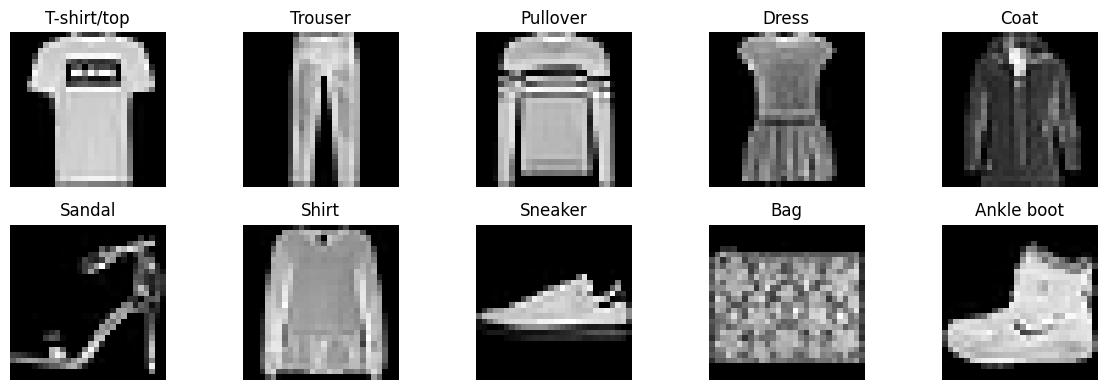

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(12, 4))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_names[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preprocess (normalize to 0–1 + one-hot labels)

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_oh  = tf.keras.utils.to_categorical(y_test, num_classes=10)

## Build ANN

In [4]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compile

In [5]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

## Train

In [6]:
history = model.fit(
    x_train, y_train_oh,
    validation_split=0.2,
    batch_size=32,
    epochs=15,
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8160 - loss: 0.5169 - val_accuracy: 0.8553 - val_loss: 0.4050
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8642 - loss: 0.3755 - val_accuracy: 0.8637 - val_loss: 0.3768
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8757 - loss: 0.3399 - val_accuracy: 0.8692 - val_loss: 0.3762
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8835 - loss: 0.3142 - val_accuracy: 0.8765 - val_loss: 0.3394
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8907 - loss: 0.2960 - val_accuracy: 0.8773 - val_loss: 0.3434
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8947 - loss: 0.2822 - val_accuracy: 0.8773 - val_loss: 0.3494
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9000 - loss: 0.2698 - val_accuracy: 0.8746 - val_loss: 0.3443
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9029 - loss: 0.2592 - 

## Evaluate on test set + metrics

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.8815
Macro Precision: 0.8849054696249151
Macro Recall: 0.8815
Macro F1: 0.8819253539387681


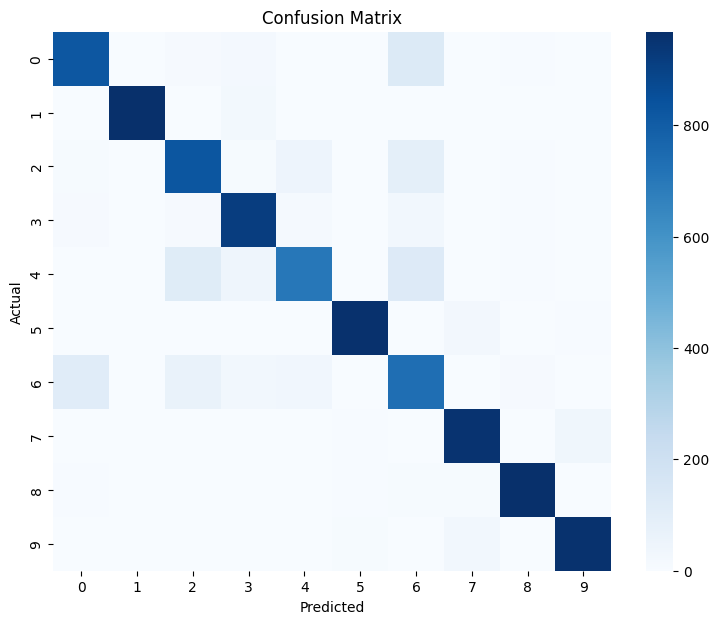

In [7]:
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Test Accuracy:", acc)
print("Macro Precision:", prec)
print("Macro Recall:", rec)
print("Macro F1:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()